<a href="https://colab.research.google.com/github/candiceburnel-sys/SGBD_M1_Ragoubi_Rayen_Burnel_Candice/blob/main/SCRIPT/Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIL Bank Transactions Analysis
**Project Overview:** Comprehensive analysis of bank transaction data including descriptive statistics, distribution visualization, demographic profiling, and suspicious activity detection.

In [11]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install openpyxl
sns.set_theme(style="whitegrid", palette="muted")

# --- COLUMN CONFIGURATION ---
# --- CONFIGURATION DES COLONNES ---
COL_AMOUNT = 'TransactionAmount'
COL_TYPE = 'TransactionType'
COL_CITY = 'Location'
COL_CHANNEL = 'Channel'
COL_AGE = 'CustomerAge'
COL_BALANCE = 'AccountBalance'

# Load the dataset
df = pd.read_excel('bank_transactions.xlsx')

display(df.head(3))

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04


## 1. Transaction Overview
Analyzing the basic statistics of transaction amounts (Mean, Max, Min).

In [12]:
mean_amount = df[COL_AMOUNT].mean()
max_amount = df[COL_AMOUNT].max()
min_amount = df[COL_AMOUNT].min()

print("--- Transaction Amount Statistics ---")
print(f"Average Transaction : € {mean_amount:,.2f}")
print(f"Maximum Transaction : € {max_amount:,.2f}")
print(f"Minimum Transaction : € {min_amount:,.2f}")

--- Transaction Amount Statistics ---
Average Transaction : € 297.59
Maximum Transaction : € 1,919.11
Minimum Transaction : € 0.26


## 2. Debit vs Credit Analysis
Comparing the volume and total value of Debit and Credit transactions, and identifying the largest transactions.

/tmp/ipykernel_4451/2861522653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=COL_TYPE, palette='Set2')


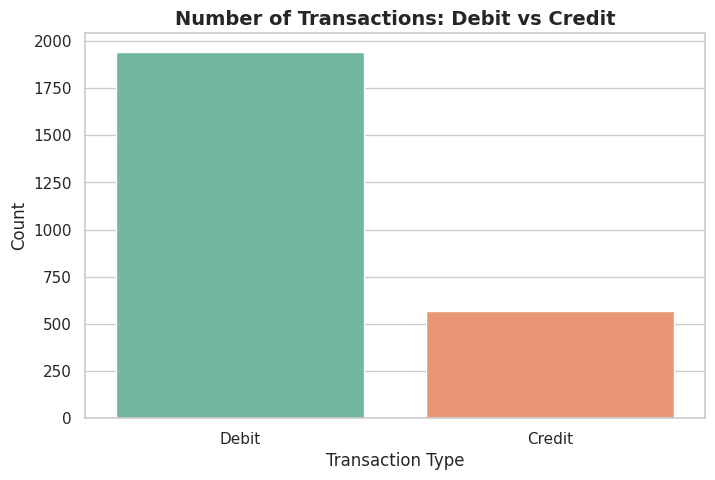


--- Total Amount by Transaction Type ---
Total Credits : € 174,092.57
Total Debits : € 573,463.00

--- Top 5 Largest Debits ---


,TransactionAmount,Location,CustomerAge
653,1919.11,Portland,30
340,1830.00,San Antonio,55
1634,1762.28,Memphis,24
2414,1664.33,San Antonio,18
1247,1647.74,Louisville,67



--- Top 5 Largest Credits ---


,TransactionAmount,Location,CustomerAge
1438,1831.02,Columbus,62
1281,1397.59,Austin,26
1625,1360.01,Phoenix,67
614,1342.25,Fort Worth,21
85,1340.19,Austin,54


In [13]:
# 1. Histogram for Count of Debit vs Credit
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=COL_TYPE, palette='Set2')
plt.title('Number of Transactions: Debit vs Credit', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

# 2. Total Sum of Debit and Credit
sum_by_type = df.groupby(COL_TYPE)[COL_AMOUNT].sum()
print("\n--- Total Amount by Transaction Type ---")
for t_type, total in sum_by_type.items():
    print(f"Total {t_type}s : € {total:,.2f}")

# 3. Show Top 5 Largest Debits
print("\n--- Top 5 Largest Debits ---")
debits = df[df[COL_TYPE].str.contains('Debit', case=False, na=False)]
display(debits.nlargest(5, COL_AMOUNT)[[COL_AMOUNT, COL_CITY, COL_AGE]])

# 4. Show Top 5 Largest Credits
print("\n--- Top 5 Largest Credits ---")
credits = df[df[COL_TYPE].str.contains('Credit', case=False, na=False)]
display(credits.nlargest(5, COL_AMOUNT)[[COL_AMOUNT, COL_CITY, COL_AGE]])

## 3. Geographical & Channel Distribution
Visualizing transaction locations and analyzing the preferred transaction channels.

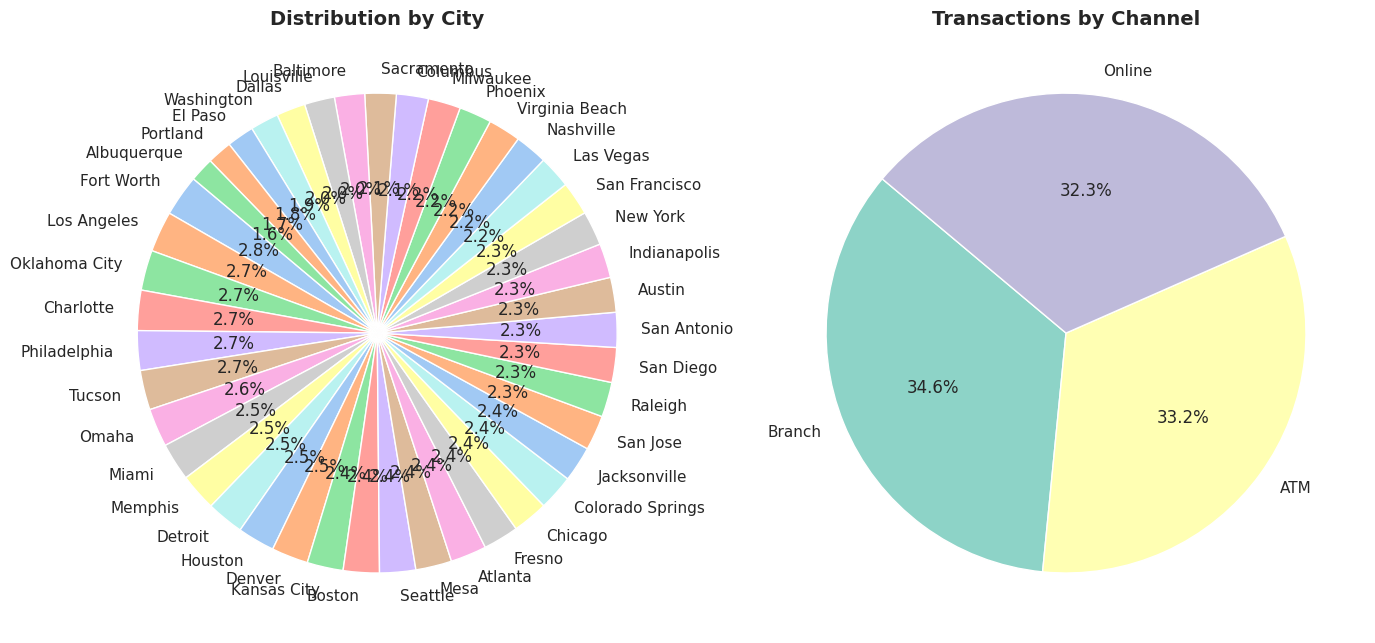


--- Percentage of Transactions by Channel ---
Channel
Branch    34.55 %
ATM       33.16 %
Online    32.29 %
Name: proportion, dtype: object


In [14]:
# 1. Pie Chart for Cities
city_counts = df[COL_CITY].value_counts()
plt.figure(figsize=(14, 7))

# Sous-graphique 1 : Villes
plt.subplot(1, 2, 1) # 1 ligne, 2 colonnes, position 1
colors_city = sns.color_palette('pastel')[0:len(city_counts)]
plt.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', startangle=140, colors=colors_city)
plt.title('Distribution by City', fontsize=14, fontweight='bold')

# 2. Pie Chart for Channels
plt.subplot(1, 2, 2) # 1 ligne, 2 colonnes, position 2
channel_counts = df[COL_CHANNEL].value_counts()
colors_channel = sns.color_palette('Set3')[0:len(channel_counts)]
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=140, colors=colors_channel)
plt.title('Transactions by Channel', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Affichage des pourcentages bruts en dessous
print("\n--- Percentage of Transactions by Channel ---")
channel_pct = df[COL_CHANNEL].value_counts(normalize=True) * 100
print(channel_pct.round(2).astype(str) + ' %')

## 4. Customer Demographics & Account Details
Analyzing customer age profiles and account balance distributions.

In [15]:
print("--- Customer Age Statistics ---")
print(f"Average Age : {df[COL_AGE].mean():.0f} years")
print(f"Maximum Age : {df[COL_AGE].max()} years")
print(f"Minimum Age : {df[COL_AGE].min()} years")

print("\n--- Account Balance Statistics ---")
print(f"Average Balance : € {df[COL_BALANCE].mean():,.2f}")
print(f"Maximum Balance : € {df[COL_BALANCE].max():,.2f}")
print(f"Minimum Balance : € {df[COL_BALANCE].min():,.2f}")

--- Customer Age Statistics ---
Average Age : 45 years
Maximum Age : 80 years
Minimum Age : 18 years

--- Account Balance Statistics ---
Average Balance : € 5,114.30
Maximum Balance : € 14,977.99
Minimum Balance : € 101.25


## 5. Suspicious Activity Detection
Flagging potentially fraudulent transactions based on behavioral rules (e.g., High transaction amounts for unusually young customers).

In [16]:
# Define what makes a transaction "suspicious"
# Rule: Age under 25 AND Amount is in the top 10% of all transactions
age_threshold = 25
amount_threshold = df[COL_AMOUNT].quantile(0.90) # Top 10% highest amounts

# Filter the dataframe based on these conditions
suspicious_tx = df[(df[COL_AGE] <= age_threshold) & (df[COL_AMOUNT] >= amount_threshold)]

print(f"--- Found {len(suspicious_tx)} Suspicious Transactions ---")
print(f"Rule applied: Customer Age <= {age_threshold} AND Amount >= € {amount_threshold:,.2f}")

# Display the most suspicious ones (highest amounts first)
display(suspicious_tx.sort_values(by=COL_AMOUNT, ascending=False).head(10))

--- Found 56 Suspicious Transactions ---
Rule applied: Customer Age <= 25 AND Amount >= € 701.31


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
1634,TX001635,AC00358,1762.28,2023-10-06 16:05:34,Debit,Memphis,D000008,26.105.49.129,M066,ATM,24,Student,150,1,1380.34,2024-11-04 08:10:42
2414,TX002415,AC00028,1664.33,2023-09-25 17:11:19,Debit,San Antonio,D000072,116.106.207.139,M064,Branch,18,Student,65,1,1588.31,2024-11-04 08:07:07
898,TX000899,AC00083,1531.31,2023-10-23 18:00:29,Debit,San Diego,D000319,91.204.200.167,M078,Online,18,Student,62,4,859.86,2024-11-04 08:06:40
1984,TX001985,AC00303,1512.99,2023-08-08 17:15:50,Debit,Philadelphia,D000032,195.164.171.146,M071,Online,19,Student,50,1,9963.39,2024-11-04 08:09:45
2201,TX002202,AC00385,1431.54,2023-12-11 16:23:59,Debit,Portland,D000490,68.254.244.208,M075,Online,20,Student,84,1,1171.98,2024-11-04 08:08:41
475,TX000476,AC00464,1431.30,2023-09-04 18:46:40,Debit,Oklahoma City,D000563,7.105.184.86,M082,ATM,18,Student,168,1,1058.13,2024-11-04 08:11:20
614,TX000615,AC00466,1342.25,2023-04-28 18:11:55,Credit,Fort Worth,D000643,28.149.72.129,M032,Branch,21,Student,235,1,694.03,2024-11-04 08:08:00
725,TX000726,AC00067,1309.79,2023-03-06 16:33:43,Debit,San Francisco,D000251,3.200.166.167,M004,ATM,23,Student,139,1,1258.93,2024-11-04 08:11:14
555,TX000556,AC00433,1282.86,2023-05-15 16:52:40,Debit,Austin,D000388,62.251.170.72,M070,Branch,19,Student,68,1,1830.98,2024-11-04 08:07:32
651,TX000652,AC00208,1241.05,2023-11-21 16:26:41,Debit,Miami,D000105,156.96.135.18,M089,Branch,18,Student,129,1,756.74,2024-11-04 08:11:48
